# Predict RVs With Saved MLP Model

This notebook runs `predict_real_ccf_mlp.py` on a new CCF input file and previews the resulting predictions.

In [637]:
from pathlib import Path
import subprocess
import shlex

import pandas as pd

import matplotlib.pyplot as plt

In [638]:
full_train_df = pd.read_parquet("./CCFs/full_iccf_dataset_normalized.parquet")


In [639]:
-224.07597700000002

-224.07597700000002

In [640]:
# Update these paths for your case
model_dir = Path("./mlp_full_model_526_256_128_64_32")
input_path = Path("./real_s1d_iccf_dataset.csv")
output_path = Path("./predicted_rv_mlp.csv")
id_col = None  # example: "spectrum_id"

assert model_dir.exists(), f"Missing model dir: {model_dir}"
assert input_path.exists(), f"Missing input file: {input_path}"

print("Model dir:", model_dir)
print("Input file:", input_path)
print("Output file:", output_path)

Model dir: mlp_full_model_526_256_128_64_32
Input file: real_s1d_iccf_dataset.csv
Output file: predicted_rv_mlp.csv


In [641]:
import json
import numpy as np
from pathlib import Path

model_dir = Path("./mlp_full_model_526_256_128_64_32")

meta = json.loads((model_dir / "preprocessing_metadata.json").read_text())
art = np.load(model_dir / "preprocessing_artifacts.npz")

print("Keys in metadata:", meta.keys())
print("Number of expected CCF columns:", len(meta["ccf_columns"]))
print("First 10 columns:", meta["ccf_columns"][:10])
print("Last 10 columns:", meta["ccf_columns"][-10:])
print("use_vrad_channel:", meta["use_vrad_channel"])

print("x_mean shape:", art["x_mean"].shape)
print("x_scale shape:", art["x_scale"].shape)


Keys in metadata: dict_keys(['ccf_columns', 'use_vrad_channel', 'n_ccf_features', 'model_type'])
Number of expected CCF columns: 301
First 10 columns: ['ccf_0000', 'ccf_0001', 'ccf_0002', 'ccf_0003', 'ccf_0004', 'ccf_0005', 'ccf_0006', 'ccf_0007', 'ccf_0008', 'ccf_0009']
Last 10 columns: ['ccf_0291', 'ccf_0292', 'ccf_0293', 'ccf_0294', 'ccf_0295', 'ccf_0296', 'ccf_0297', 'ccf_0298', 'ccf_0299', 'ccf_0300']
use_vrad_channel: False
x_mean shape: (301,)
x_scale shape: (301,)


In [642]:
input_df = pd.read_csv("real_s1d_iccf_dataset.csv")

missing = [c for c in meta["ccf_columns"] if c not in input_df.columns]
extra = [c for c in input_df.columns if c not in meta["ccf_columns"]]

print("Missing expected columns:", missing[:20], "count =", len(missing))
print("Extra columns:", extra[:20], "count =", len(extra))

compatible_df = input_df[meta["ccf_columns"]].copy()
clean_input_path = Path("./real_s1d_iccf_dataset_clean.csv")
compatible_df.to_csv(clean_input_path, index=False)
print("Saved cleaned input to:", clean_input_path)

import pandas as pd
from pathlib import Path

#input_df = pd.read_csv(input_path).copy()

# Keep only the columns expected by the trained model
compatible_df = input_df[meta["ccf_columns"]].copy()

# Normalize each row by its maximum CCF value, exactly as in process_ccf.py
ccf_cols = meta["ccf_columns"]
row_max = compatible_df[ccf_cols].max(axis=1)
compatible_df[ccf_cols] = compatible_df[ccf_cols].div(row_max, axis=0)
compatible_df[ccf_cols] = compatible_df[ccf_cols].round(4)

clean_input_path = Path("./real_ccf_model_input_normalized.csv")
compatible_df.to_csv(clean_input_path, index=False)

print("Saved normalized model input to:", clean_input_path)
compatible_df.head()



Missing expected columns: [] count = 0
Extra columns: ['rv_iccf_mps', 'fwhm_kms', 'bis_mps', 'vspan_mps', 'wspan_mps', 'contrast_percent', 'source_file', 'source_path', 'object', 'date_obs', 'mjd_obs', 'berv_kms', 'bervmax_kms', 'n_used_pixels'] count = 14
Saved cleaned input to: real_s1d_iccf_dataset_clean.csv
Saved normalized model input to: real_ccf_model_input_normalized.csv


,ccf_0000,ccf_0001,ccf_0002,ccf_0003,ccf_0004,ccf_0005,ccf_0006,ccf_0007,ccf_0008,ccf_0009,...,ccf_0291,ccf_0292,ccf_0293,ccf_0294,ccf_0295,ccf_0296,ccf_0297,ccf_0298,ccf_0299,ccf_0300
0,0.9944,0.9944,0.9943,0.9942,0.9942,0.9942,0.9941,0.9942,0.9942,0.9943,...,0.9989,0.9989,0.9989,0.9988,0.9988,0.9989,0.9989,0.9990,0.9990,0.9989
1,0.9943,0.9943,0.9943,0.9943,0.9943,0.9943,0.9943,0.9944,0.9944,0.9945,...,0.9991,0.9990,0.9990,0.9989,0.9989,0.9988,0.9986,0.9985,0.9984,0.9983
2,0.9945,0.9945,0.9945,0.9945,0.9945,0.9945,0.9945,0.9945,0.9945,0.9946,...,0.9991,0.9991,0.9992,0.9992,0.9991,0.9991,0.9990,0.9989,0.9988,0.9987
3,0.9937,0.9938,0.9938,0.9938,0.9937,0.9937,0.9937,0.9937,0.9937,0.9937,...,0.9984,0.9984,0.9985,0.9985,0.9985,0.9984,0.9984,0.9983,0.9983,0.9983
4,0.9937,0.9936,0.9936,0.9936,0.9936,0.9936,0.9937,0.9937,0.9937,0.9938,...,0.9986,0.9985,0.9985,0.9985,0.9985,0.9984,0.9984,0.9983,0.9982,0.9982


In [643]:
head = full_train_df[meta['ccf_columns']].head(5)

In [644]:
#plt.scatter( full_train_df.rv_true_mps, full_train_df.rv_iccf_mps +224)

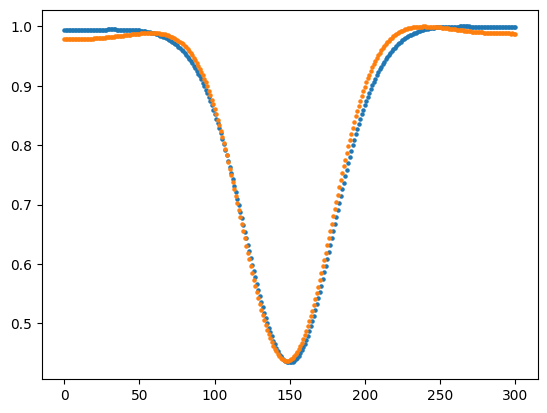

In [645]:
plt.scatter(np.arange(301), compatible_df.iloc[1][meta["ccf_columns"]].values, s = 5)
plt.scatter(np.arange(301), head.iloc[4][meta["ccf_columns"]].values, s = 5)
#plt.xlim(120,170)

In [646]:
cmd = [
    "python",
    "predict_real_ccf_mlp.py",
    "--model-dir", str(model_dir),
    "--input-path", str(clean_input_path),
    "--output-path", str(output_path),
]

if id_col is not None:
    cmd.extend(["--id-col", id_col])

print("Running:")
print(" ".join(shlex.quote(x) for x in cmd))

result = subprocess.run(cmd, capture_output=True, text=True)

print("returncode:", result.returncode)
print("\nSTDOUT:\n", result.stdout if result.stdout else "<empty>")
print("\nSTDERR:\n", result.stderr if result.stderr else "<empty>")

if result.returncode != 0:
    raise RuntimeError(f"Prediction failed with code {result.returncode}")

Running:
python predict_real_ccf_mlp.py --model-dir mlp_full_model_526_256_128_64_32 --input-path real_ccf_model_input_normalized.csv --output-path predicted_rv_mlp.csv
returncode: 0

STDOUT:
 Saved predictions to predicted_rv_mlp.csv
 sample_index  predicted_rv_mps
            0        299.532562
            1        300.022766
            2        296.923615
            3        304.616516
            4        204.838562
            5        300.288605
            6        301.473083


STDERR:
 2026-04-15 10:43:26.471055: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-15 10:43:26.489951: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been regis

In [647]:
input_df.head(2)

,rv_iccf_mps,fwhm_kms,bis_mps,vspan_mps,wspan_mps,contrast_percent,source_file,source_path,object,date_obs,...,ccf_0291,ccf_0292,ccf_0293,ccf_0294,ccf_0295,ccf_0296,ccf_0297,ccf_0298,ccf_0299,ccf_0300
0,-2564.712049,6.994422,-63.540433,-56.594103,97.571415,56.325515,r.ESPRE.2018-07-09T04:49:52.650_S1D_A.fits,S1D_spectra/r.ESPRE.2018-07-09T04:49:52.650_S1...,vesta,2018-07-09T04:49:52.649,...,6.218082e+07,6.218035e+07,6.217818e+07,6.217607e+07,6.217490e+07,6.217778e+07,6.218036e+07,6.218247e+07,6.218275e+07,6.217850e+07
1,-2564.670704,6.998459,-61.738868,-55.347667,98.862886,56.337160,r.ESPRE.2018-07-09T04:54:31.618_S1D_A.fits,S1D_spectra/r.ESPRE.2018-07-09T04:54:31.618_S1...,vesta,2018-07-09T04:54:31.618,...,6.694999e+07,6.694695e+07,6.694338e+07,6.694027e+07,6.693614e+07,6.692994e+07,6.692073e+07,6.691157e+07,6.690544e+07,6.689924e+07


In [648]:
input_df['rv_iccf_mps_shifted'] = input_df['rv_iccf_mps'] - input_df['rv_iccf_mps'].mean()
#input_df['rv_iccf_mps_shifted'].head(9)

In [649]:
predicted_rv = pd.read_csv('predicted_rv_mlp.csv')
predicted_rv['predicted_rv_mps_shifted'] = predicted_rv ['predicted_rv_mps'] - predicted_rv ['predicted_rv_mps'].mean()
#predicted_rv['predicted_rv_mps_shifted'].head(9)

In [650]:
(predicted_rv['predicted_rv_mps_shifted'] -input_df['rv_iccf_mps_shifted']).describe()

count    7.000000e+00
mean     1.705303e-13
std      3.867499e+01
min     -8.604801e+01
25%      7.224646e+00
50%      7.963335e+00
75%      1.939977e+01
max      2.483584e+01
dtype: float64

count    2.700000e+01
mean    -1.284240e-13
std      6.635317e+00
min     -1.290941e+01
25%     -3.831947e+00
50%     -8.066038e-01
75%      5.310723e+00
max      1.086008e+01
dtype: float64

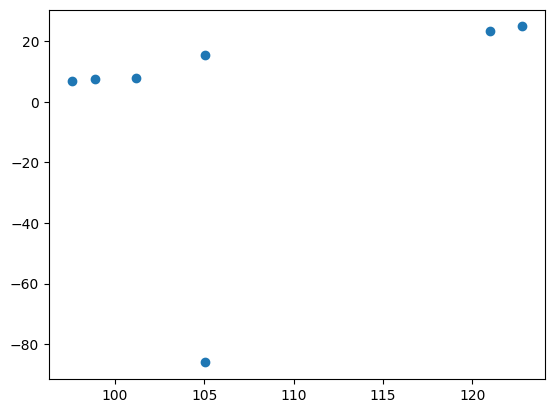

In [651]:
plt.scatter(input_df.wspan_mps, predicted_rv['predicted_rv_mps_shifted'] - input_df['rv_iccf_mps_shifted'] )

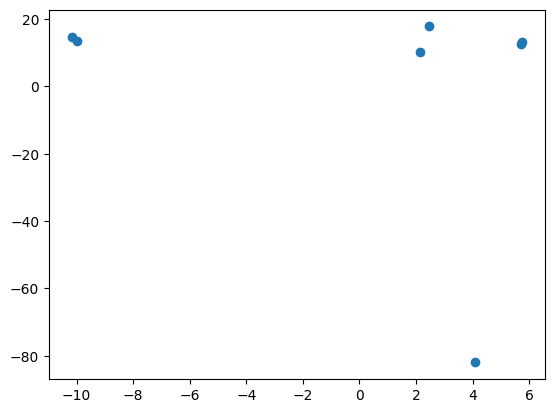

In [652]:
plt.scatter(input_df['rv_iccf_mps_shifted'], predicted_rv['predicted_rv_mps_shifted'])


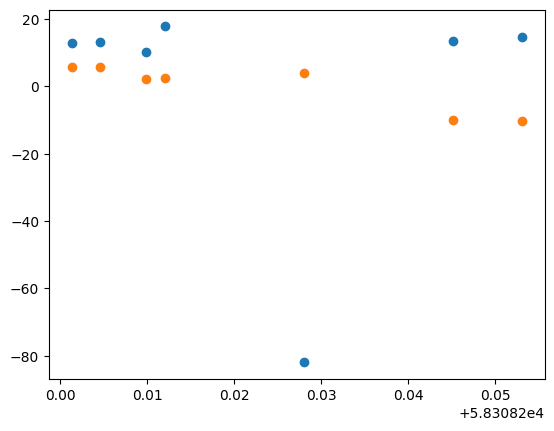

In [653]:
plt.scatter(input_df.mjd_obs, predicted_rv['predicted_rv_mps_shifted'])
plt.scatter(input_df.mjd_obs,  input_df['rv_iccf_mps_shifted'])
#plt.ylim(-5,5)